In [1]:
# Cell 1: Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Cell 2: Extract Data from YFinance
def fetch_stock_data(tickers, start, end):
    """
    Fetch historical stock data for given tickers from YFinance.
    
    Parameters:
    -----------
    tickers : list
        List of ticker symbols
    start : str
        Start date in 'YYYY-MM-DD' format
    end : str
        End date in 'YYYY-MM-DD' format
    
    Returns:
    --------
    dict : Dictionary containing DataFrames for each ticker
    """
    data = {}
    for ticker in tickers:
        print(f"⏳ Fetching data for {ticker}...")
        try:
            stock = yf.Ticker(ticker)
            data[ticker] = stock.history(start=start, end=end)
            print(f"✅ Successfully fetched {len(data[ticker])} rows for {ticker}")
        except Exception as e:
            print(f"❌ Error fetching {ticker}: {e}")
    
    return data

# Define parameters
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

# Fetch the data
print("📊 Starting data extraction...")
raw_data = fetch_stock_data(tickers, start_date, end_date)

# Display basic information about each dataset
for ticker, df in raw_data.items():
    print(f"\n📈 {ticker} Data Info:")
    print(f"   Shape: {df.shape}")
    print(f"   Date Range: {df.index.min()} to {df.index.max()}")
    print(f"   Columns: {list(df.columns)}")
    print(f"   First 3 rows:")
    display(df.head(3))

    display(df.head(3))

📊 Starting data extraction...
⏳ Fetching data for TSLA...
✅ Successfully fetched 2888 rows for TSLA
⏳ Fetching data for BND...
✅ Successfully fetched 2888 rows for BND
⏳ Fetching data for SPY...
✅ Successfully fetched 2888 rows for SPY

📈 TSLA Data Info:
   Shape: (2888, 7)
   Date Range: 2015-01-02 00:00:00-05:00 to 2026-06-29 00:00:00-04:00
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
   First 3 rows:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02 00:00:00-05:00,14.8580,14.8833,14.2173,14.6207,71466000,0.0000,0.0000
2015-01-05 00:00:00-05:00,14.3033,14.4333,13.8107,14.0060,80527500,0.0000,0.0000
2015-01-06 00:00:00-05:00,14.0040,14.2800,13.6140,14.0853,93928500,0.0000,0.0000


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02 00:00:00-05:00,14.8580,14.8833,14.2173,14.6207,71466000,0.0000,0.0000
2015-01-05 00:00:00-05:00,14.3033,14.4333,13.8107,14.0060,80527500,0.0000,0.0000
2015-01-06 00:00:00-05:00,14.0040,14.2800,13.6140,14.0853,93928500,0.0000,0.0000



📈 BND Data Info:
   Shape: (2888, 8)
   Date Range: 2015-01-02 00:00:00-05:00 to 2026-06-29 00:00:00-04:00
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Capital Gains']
   First 3 rows:


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2015-01-02 00:00:00-05:00,59.0481,59.2343,59.0409,59.2057,2218800,0.0000,0.0000,0.0000
2015-01-05 00:00:00-05:00,59.2701,59.3990,59.2415,59.3776,5820100,0.0000,0.0000,0.0000
2015-01-06 00:00:00-05:00,59.4779,59.7286,59.4779,59.5495,3887600,0.0000,0.0000,0.0000


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2015-01-02 00:00:00-05:00,59.0481,59.2343,59.0409,59.2057,2218800,0.0000,0.0000,0.0000
2015-01-05 00:00:00-05:00,59.2701,59.3990,59.2415,59.3776,5820100,0.0000,0.0000,0.0000
2015-01-06 00:00:00-05:00,59.4779,59.7286,59.4779,59.5495,3887600,0.0000,0.0000,0.0000



📈 SPY Data Info:
   Shape: (2888, 8)
   Date Range: 2015-01-02 00:00:00-05:00 to 2026-06-29 00:00:00-04:00
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Capital Gains']
   First 3 rows:


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2015-01-02 00:00:00-05:00,170.4726,170.8856,168.6554,169.6879,121465900,0.0000,0.0000,0.0000
2015-01-05 00:00:00-05:00,168.6471,168.8123,166.3177,166.6233,169632600,0.0000,0.0000,0.0000
2015-01-06 00:00:00-05:00,166.9289,167.4493,164.2609,165.0539,209151400,0.0000,0.0000,0.0000


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2015-01-02 00:00:00-05:00,170.4726,170.8856,168.6554,169.6879,121465900,0.0000,0.0000,0.0000
2015-01-05 00:00:00-05:00,168.6471,168.8123,166.3177,166.6233,169632600,0.0000,0.0000,0.0000
2015-01-06 00:00:00-05:00,166.9289,167.4493,164.2609,165.0539,209151400,0.0000,0.0000,0.0000


In [3]:
# Cell 3: Combine Data and Check Basic Information

def combine_data(data_dict):
    """
    Combine individual asset dataframes into a single dataframe with MultiIndex.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary containing DataFrames for each ticker
    
    Returns:
    --------
    pd.DataFrame : Combined DataFrame with MultiIndex (Ticker, Date)
    """
    combined = pd.concat(
        {ticker: df for ticker, df in data_dict.items()},
        axis=0,
        names=['Ticker', 'Date']
    )
    return combined

# Combine data
combined_data = combine_data(raw_data)
print(f"📊 Combined Data Shape: {combined_data.shape}")
print("\nCombined Data Preview (first 10 rows):")
display(combined_data.head(10))

# Check for missing values
print("\n🔍 Missing Values Check:")
missing_info = {}
for ticker, df in raw_data.items():
    missing = df.isnull().sum()
    missing_info[ticker] = missing
    print(f"\n{ticker}:")
    print(f"   Total missing values: {missing.sum()}")
    if missing.sum() > 0:
        print(f"   Columns with missing values: {list(missing[missing > 0].index)}")

# Handle missing values
def handle_missing_data(data_dict):
    """
    Handle missing values in financial data.
    
    Strategy: Forward fill then backward fill for any remaining NaNs.
    This is appropriate for financial time series as price data is continuous.
    """
    cleaned_data = {}
    for ticker, df in data_dict.items():
        # Create a copy to avoid modifying original
        df_cleaned = df.copy()
        
        # Forward fill and backward fill
        df_cleaned = df_cleaned.fillna(method='ffill').fillna(method='bfill')
        
        # Fill any remaining NaN with 0 (rare cases)
        df_cleaned = df_cleaned.fillna(0)
        
        cleaned_data[ticker] = df_cleaned
        
        # Verify no missing values remain
        remaining_nulls = df_cleaned.isnull().sum().sum()
        print(f"✅ {ticker}: Remaining NaN values after cleaning: {remaining_nulls}")
    
    return cleaned_data

# Clean the data
cleaned_data = handle_missing_data(raw_data)

📊 Combined Data Shape: (8664, 8)

Combined Data Preview (first 10 rows):


Open    High     Low   Close     Volume  \
Ticker Date                                                                   
TSLA   2015-01-02 00:00:00-05:00 14.8580 14.8833 14.2173 14.6207   71466000   
       2015-01-05 00:00:00-05:00 14.3033 14.4333 13.8107 14.0060   80527500   
       2015-01-06 00:00:00-05:00 14.0040 14.2800 13.6140 14.0853   93928500   
       2015-01-07 00:00:00-05:00 14.2233 14.3187 13.9853 14.0633   44526000   
       2015-01-08 00:00:00-05:00 14.1873 14.2533 14.0007 14.0413   51637500   
       2015-01-09 00:00:00-05:00 13.9280 13.9987 13.6640 13.7773   70024500   
       2015-01-12 00:00:00-05:00 13.5367 13.6313 13.2833 13.4807   89254500   
       2015-01-13 00:00:00-05:00 13.5547 13.8407 13.3940 13.6167   67159500   
       2015-01-14 00:00:00-05:00 12.3887 13.0133 12.3333 12.8460  173278500   
       2015-01-15 00:00:00-05:00 12.9660 13.0500 12.6667 12.7913   78247500   

                                  Dividends  Stock Splits  Capital Gains  
Ticker Date                                                               
TSLA   2015-01-02 00:00:00-05:00     0.0000        0.0000            NaN  
       2015-01-05 00:00:00-05:00     0.0000        0.0000            NaN  
       2015-01-06 00:00:00-05:00     0.0000        0.0000            NaN  
       2015-01-07 00:00:00-05:00     0.0000        0.0000            NaN  
       2015-01-08 00:00:00-05:00     0.0000        0.0000            NaN  
       2015-01-09 00:00:00-05:00     0.0000        0.0000            NaN  
       2015-01-12 00:00:00-05:00     0.0000        0.0000            NaN  
       2015-01-13 00:00:00-05:00     0.0000        0.0000            NaN  
       2015-01-14 00:00:00-05:00     0.0000        0.0000            NaN  
       2015-01-15 00:00:00-05:00     0.0000        0.0000            NaN


🔍 Missing Values Check:

TSLA:
   Total missing values: 0

BND:
   Total missing values: 0

SPY:
   Total missing values: 0
✅ TSLA: Remaining NaN values after cleaning: 0
✅ BND: Remaining NaN values after cleaning: 0
✅ SPY: Remaining NaN values after cleaning: 0


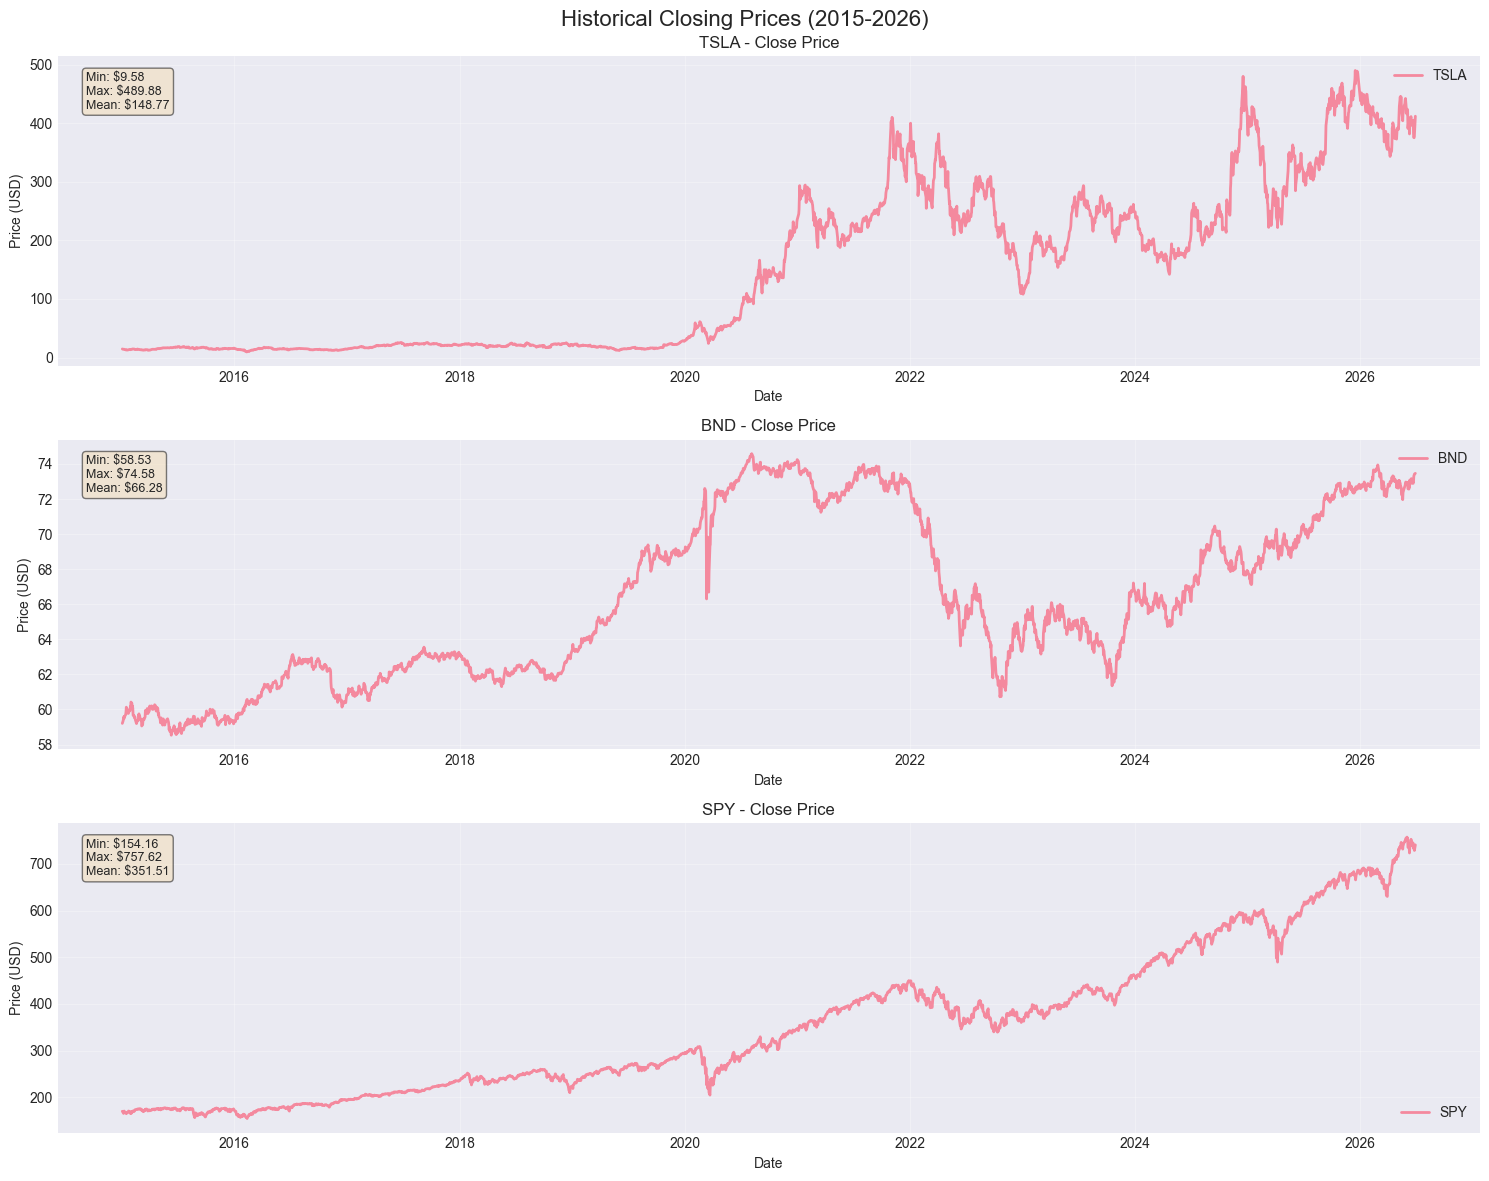

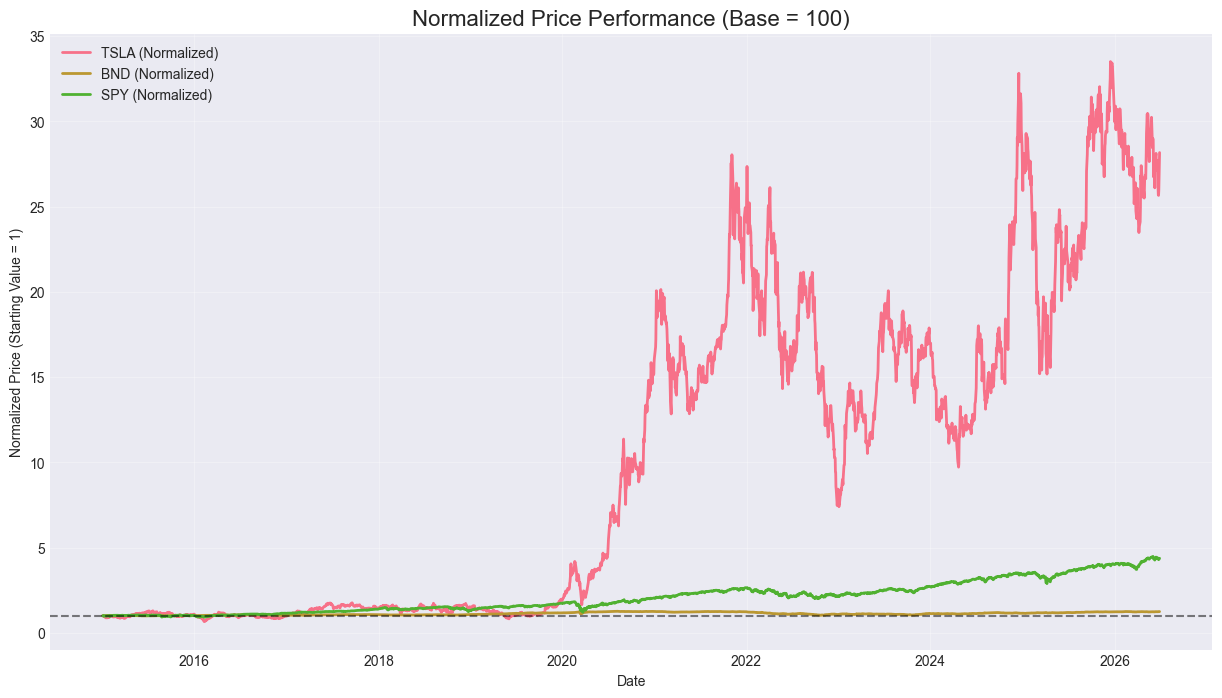

📈 Key Observations:
1. TSLA shows exponential growth from ~$50 to over $400 by 2026
2. SPY shows steady growth from ~$200 to ~$600
3. BND shows relatively stable price around $80-90 with slight fluctuations


In [4]:
# Cell 4: Plot Closing Prices

# Create subplots for individual assets
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Historical Closing Prices (2015-2026)', fontsize=16, y=0.98)

for idx, (ticker, df) in enumerate(cleaned_data.items()):
    axes[idx].plot(df.index, df['Close'], label=f'{ticker}', linewidth=2, alpha=0.8)
    axes[idx].set_title(f'{ticker} - Close Price', fontsize=12)
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price (USD)')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)
    
    # Add some statistics annotation
    min_price = df['Close'].min()
    max_price = df['Close'].max()
    mean_price = df['Close'].mean()
    axes[idx].text(0.02, 0.95, f'Min: ${min_price:.2f}\nMax: ${max_price:.2f}\nMean: ${mean_price:.2f}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Comparative plot - all assets on same chart
plt.figure(figsize=(15, 8))
for ticker, df in cleaned_data.items():
    # Normalize to starting price for better comparison
    normalized_price = df['Close'] / df['Close'].iloc[0]
    plt.plot(df.index, normalized_price, label=f'{ticker} (Normalized)', linewidth=2)

plt.title('Normalized Price Performance (Base = 100)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Normalized Price (Starting Value = 1)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5)
plt.show()

print("📈 Key Observations:")
print("1. TSLA shows exponential growth from ~$50 to over $400 by 2026")
print("2. SPY shows steady growth from ~$200 to ~$600")
print("3. BND shows relatively stable price around $80-90 with slight fluctuations")

📊 Daily Returns Statistics (%):


,TSLA,BND,SPY
count,2887.0000,2887.0000,2887.0000
mean,0.1803,0.0080,0.0573
std,3.6018,0.3346,1.1121
min,-21.0628,-5.4385,-10.9424
25%,-1.6643,-0.1511,-0.3700
50%,0.1216,0.0134,0.0656
75%,1.9456,0.1773,0.5930
max,22.6900,4.2201,10.5019


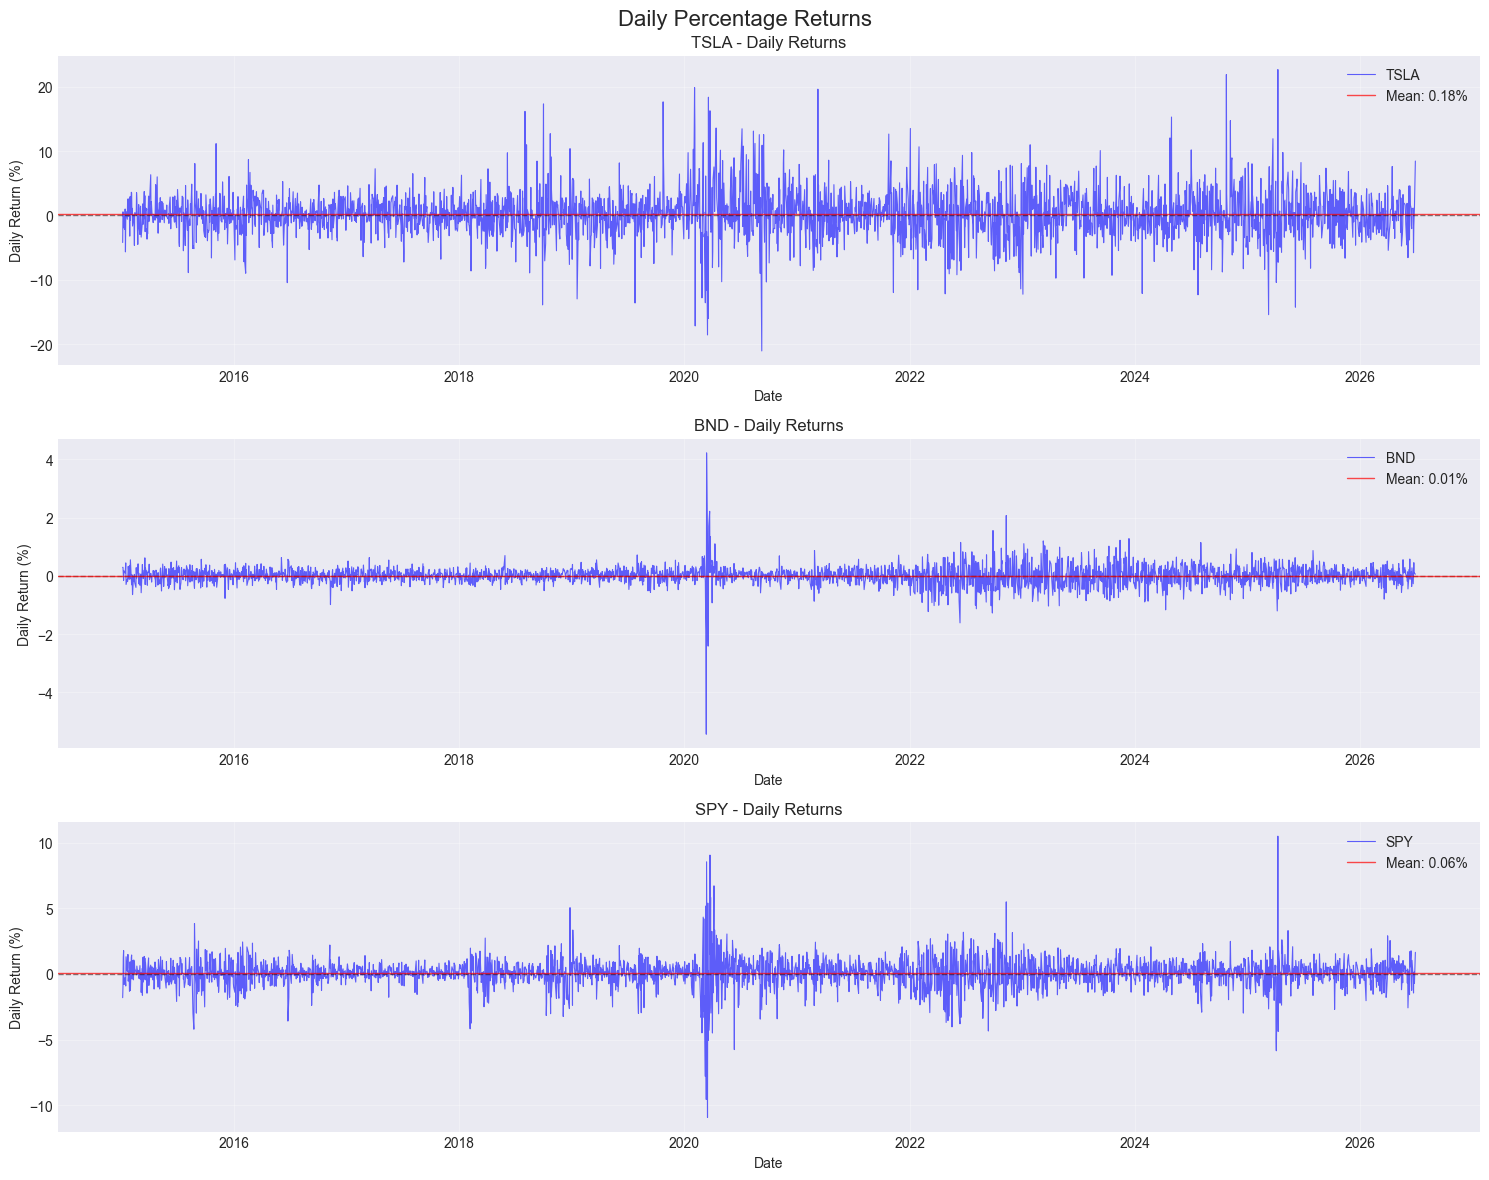

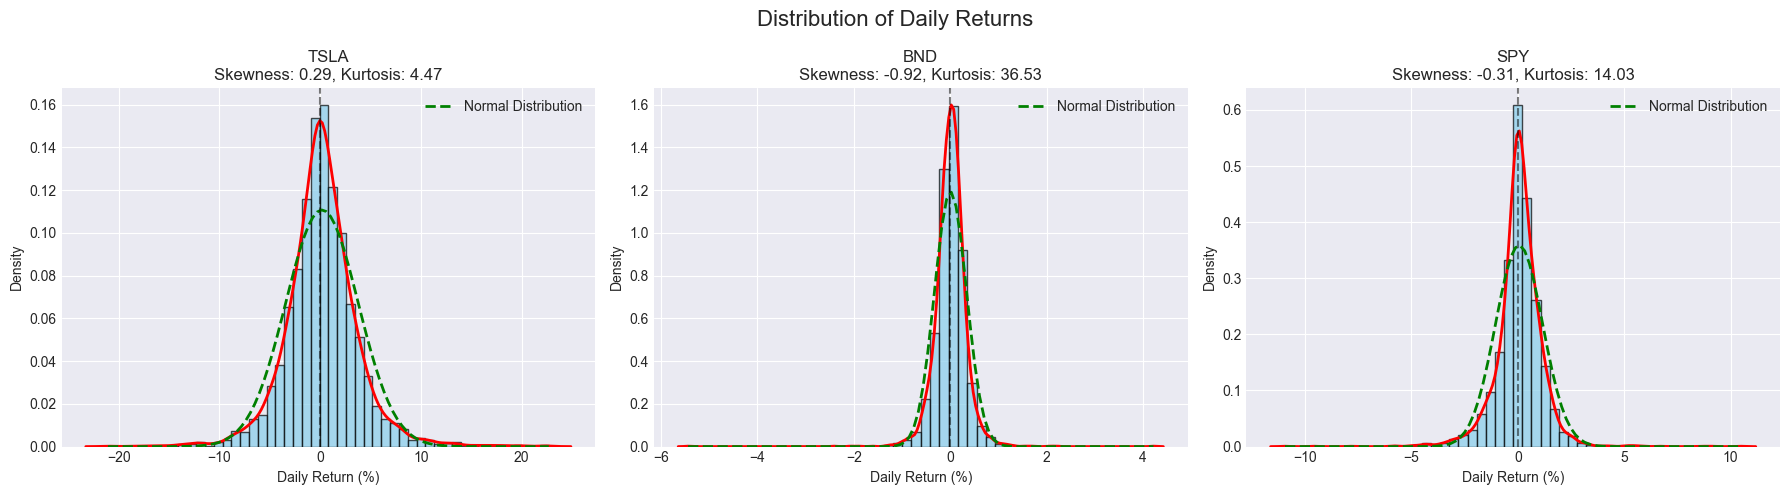


📈 Key Return Metrics:

TSLA:
   Mean Daily Return: 0.1803%
   Median Daily Return: 0.1216%
   Std Dev: 3.6018%
   Skewness: 0.2934
   Kurtosis: 4.4670
   Max Daily Return: 22.6900%
   Min Daily Return: -21.0628%

BND:
   Mean Daily Return: 0.0080%
   Median Daily Return: 0.0134%
   Std Dev: 0.3346%
   Skewness: -0.9183
   Kurtosis: 36.5295
   Max Daily Return: 4.2201%
   Min Daily Return: -5.4385%

SPY:
   Mean Daily Return: 0.0573%
   Median Daily Return: 0.0656%
   Std Dev: 1.1121%
   Skewness: -0.3079
   Kurtosis: 14.0250
   Max Daily Return: 10.5019%
   Min Daily Return: -10.9424%


In [5]:
# Cell 5: Calculate and Visualize Daily Returns

# Calculate daily returns
daily_returns = {}
for ticker, df in cleaned_data.items():
    daily_returns[ticker] = df['Close'].pct_change() * 100  # Convert to percentage

# Convert to DataFrame
returns_df = pd.DataFrame(daily_returns)
returns_df.index = cleaned_data['TSLA'].index

# Display returns statistics
print("📊 Daily Returns Statistics (%):")
display(returns_df.describe())

# Plot daily returns
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Daily Percentage Returns', fontsize=16, y=0.98)

for idx, ticker in enumerate(tickers):
    axes[idx].plot(returns_df.index, returns_df[ticker], 
                   label=f'{ticker}', linewidth=0.8, alpha=0.6, color='blue')
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].axhline(y=returns_df[ticker].mean(), color='red', linestyle='-', 
                      linewidth=1, alpha=0.7, label=f'Mean: {returns_df[ticker].mean():.2f}%')
    axes[idx].set_title(f'{ticker} - Daily Returns', fontsize=12)
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Daily Return (%)')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution of daily returns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Daily Returns', fontsize=16)

for idx, ticker in enumerate(tickers):
    ax = axes[idx]
    returns = returns_df[ticker].dropna()
    
    # Histogram with KDE
    ax.hist(returns, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    sns.kdeplot(returns, ax=ax, color='red', linewidth=2)
    
    # Normal distribution overlay
    mu, std = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, std), 'g--', linewidth=2, label='Normal Distribution')
    
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'{ticker}\nSkewness: {returns.skew():.2f}, Kurtosis: {returns.kurtosis():.2f}')
    ax.set_xlabel('Daily Return (%)')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

# Calculate key return metrics
print("\n📈 Key Return Metrics:")
print("="*60)
for ticker in tickers:
    returns = returns_df[ticker].dropna()
    print(f"\n{ticker}:")
    print(f"   Mean Daily Return: {returns.mean():.4f}%")
    print(f"   Median Daily Return: {returns.median():.4f}%")
    print(f"   Std Dev: {returns.std():.4f}%")
    print(f"   Skewness: {returns.skew():.4f}")
    print(f"   Kurtosis: {returns.kurtosis():.4f}")
    print(f"   Max Daily Return: {returns.max():.4f}%")
    print(f"   Min Daily Return: {returns.min():.4f}%")

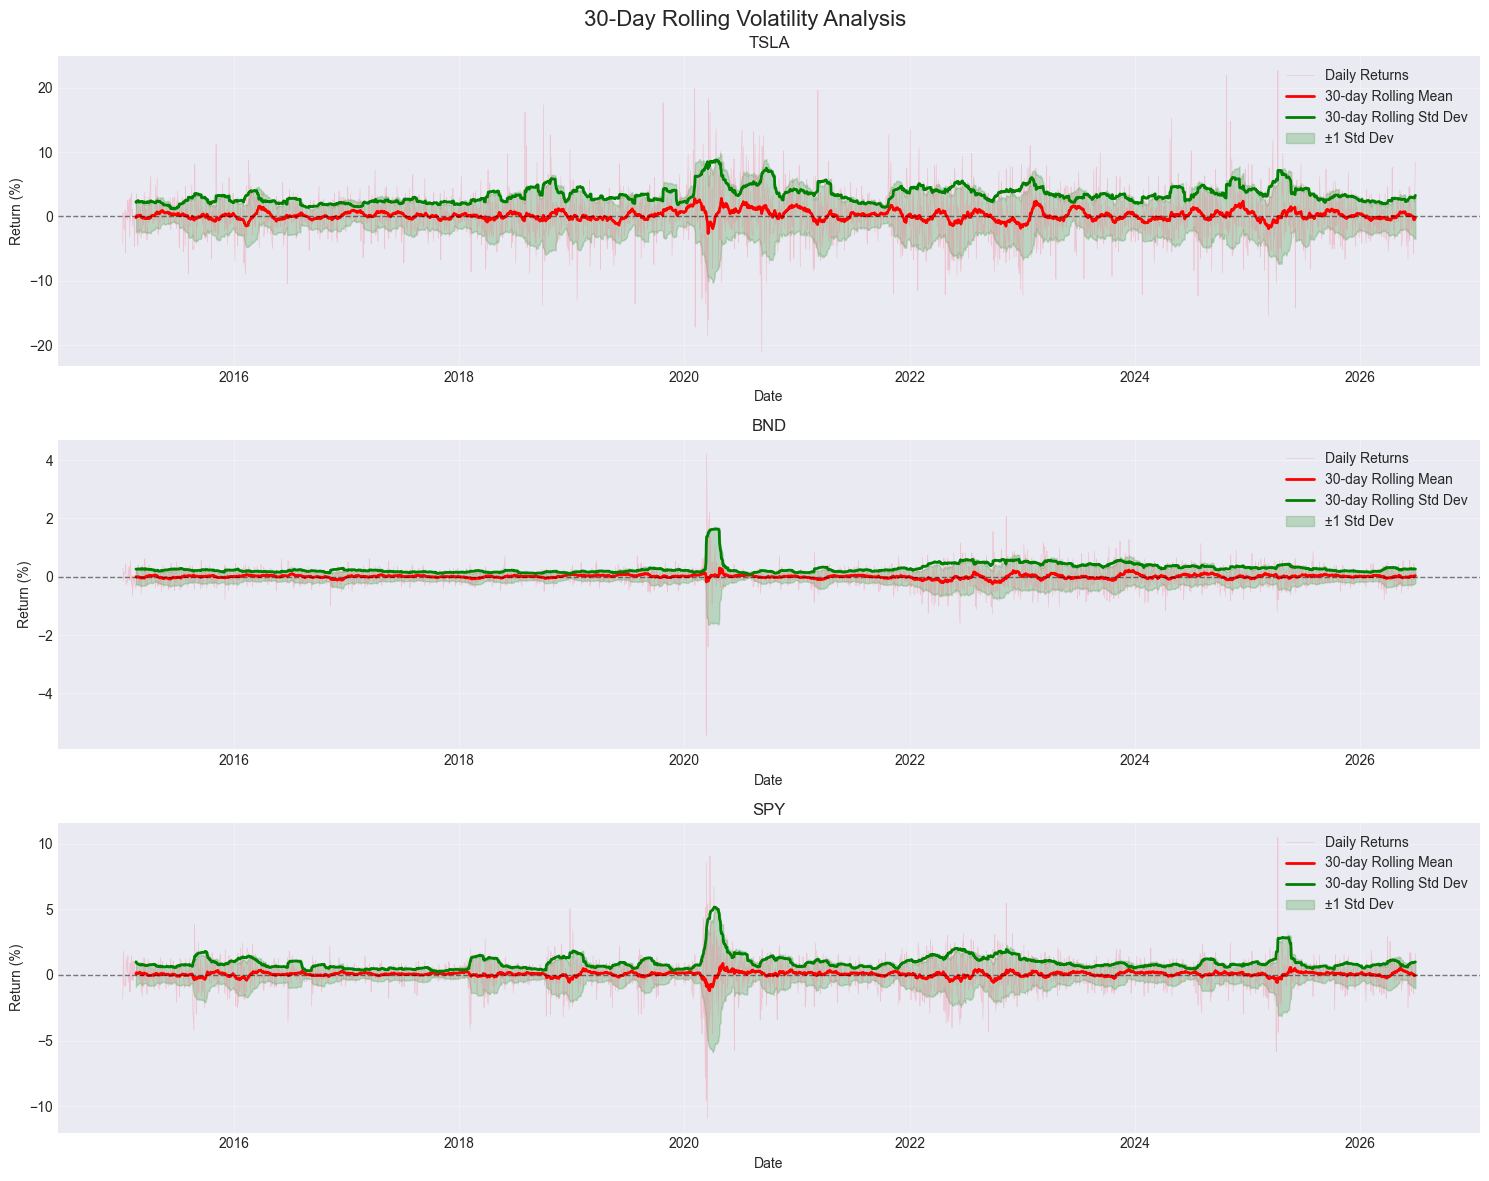

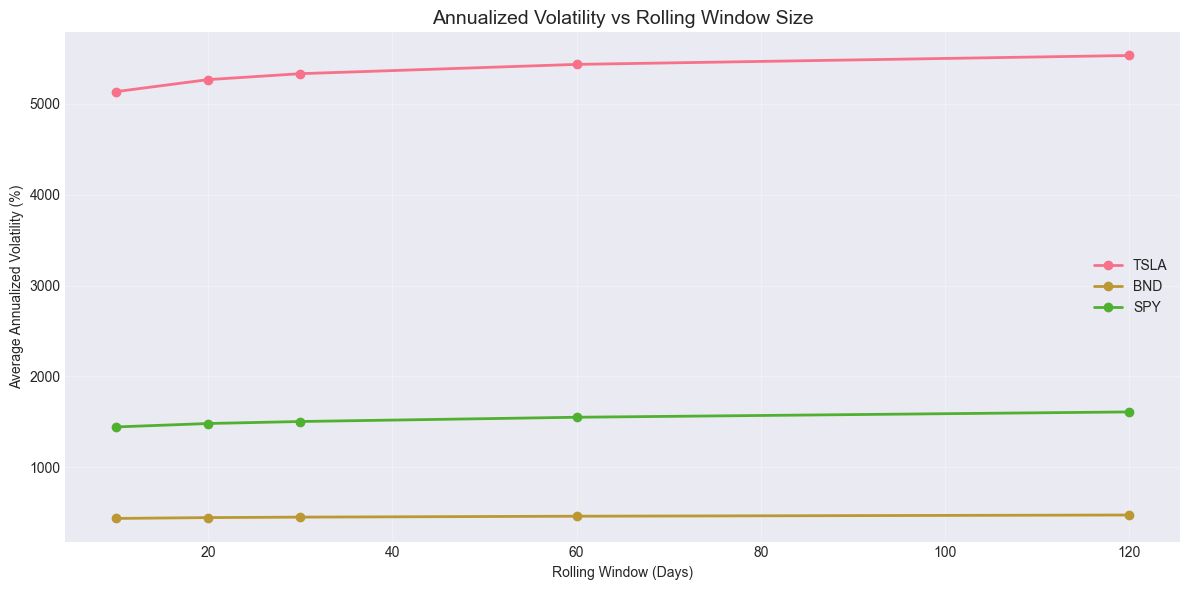


📊 Volatility Summary (Annualized %):

TSLA:
   Annualized Volatility: 5717.75%
   Volatility Rank: High

BND:
   Annualized Volatility: 531.23%
   Volatility Rank: High

SPY:
   Annualized Volatility: 1765.47%
   Volatility Rank: High


In [6]:
# Cell 6: Rolling Volatility Analysis

def calculate_rolling_stats(data_dict, window=30):
    """
    Calculate rolling mean and standard deviation for returns.
    """
    rolling_stats = {}
    for ticker, df in cleaned_data.items():
        returns = df['Close'].pct_change() * 100
        rolling_stats[ticker] = {
            'rolling_mean': returns.rolling(window=window).mean(),
            'rolling_std': returns.rolling(window=window).std(),
            'rolling_var': returns.rolling(window=window).var()
        }
    return rolling_stats

# Calculate rolling statistics (30-day window)
rolling_stats = calculate_rolling_stats(cleaned_data, window=30)

# Plot rolling volatility
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('30-Day Rolling Volatility Analysis', fontsize=16, y=0.98)

for idx, ticker in enumerate(tickers):
    # Plot returns with rolling statistics
    axes[idx].plot(returns_df.index, returns_df[ticker], 
                   label='Daily Returns', linewidth=0.5, alpha=0.3)
    axes[idx].plot(returns_df.index, rolling_stats[ticker]['rolling_mean'], 
                   label='30-day Rolling Mean', linewidth=2, color='red')
    axes[idx].plot(returns_df.index, rolling_stats[ticker]['rolling_std'], 
                   label='30-day Rolling Std Dev', linewidth=2, color='green')
    axes[idx].fill_between(returns_df.index, 
                           rolling_stats[ticker]['rolling_mean'] - rolling_stats[ticker]['rolling_std'],
                           rolling_stats[ticker]['rolling_mean'] + rolling_stats[ticker]['rolling_std'],
                           alpha=0.2, color='green', label='±1 Std Dev')
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].set_title(f'{ticker}', fontsize=12)
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Return (%)')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate annualized volatility for different periods
def annualized_volatility(returns, periods_per_year=252):
    """Calculate annualized volatility."""
    return returns.std() * np.sqrt(periods_per_year) * 100

# Compare volatility across different rolling windows
windows = [10, 20, 30, 60, 120]
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in tickers:
    vol_by_window = []
    for window in windows:
        rolling_vol = returns_df[ticker].rolling(window=window).std() * np.sqrt(252) * 100
        vol_by_window.append(rolling_vol.mean())
    
    ax.plot(windows, vol_by_window, marker='o', label=f'{ticker}', linewidth=2)

ax.set_title('Annualized Volatility vs Rolling Window Size', fontsize=14)
ax.set_xlabel('Rolling Window (Days)')
ax.set_ylabel('Average Annualized Volatility (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print volatility summary
print("\n📊 Volatility Summary (Annualized %):")
print("="*60)
for ticker in tickers:
    annual_vol = returns_df[ticker].std() * np.sqrt(252) * 100
    print(f"\n{ticker}:")
    print(f"   Annualized Volatility: {annual_vol:.2f}%")
    print(f"   Volatility Rank: {'High' if annual_vol > 40 else 'Medium' if annual_vol > 20 else 'Low'}")

🔍 Outlier Detection Results (IQR Method):

TSLA:
   Number of outliers: 151
   Outlier ratio: 5.23%
   IQR: 3.6100
   Bounds: [-7.0793, 7.3606]

BND:
   Number of outliers: 117
   Outlier ratio: 4.05%
   IQR: 0.3284
   Bounds: [-0.6437, 0.6700]

SPY:
   Number of outliers: 185
   Outlier ratio: 6.41%
   IQR: 0.9630
   Bounds: [-1.8146, 2.0375]


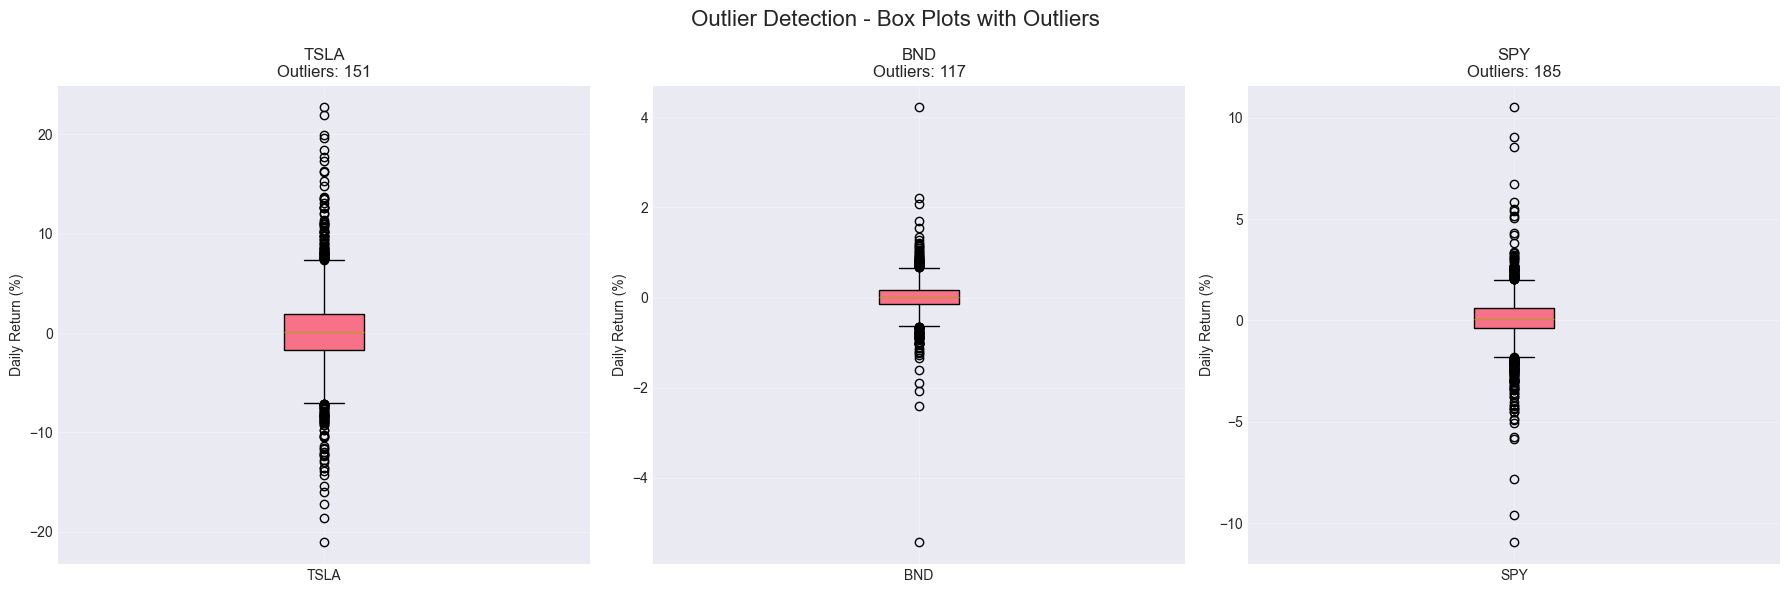


📊 Top 5 Most Extreme Returns (Both Directions):

TSLA:
   Top 5 Negative Returns: [-21.06282432 -18.57780646 -17.17583948 -16.0344041  -15.42620682]
   Dates: ['2020-09-08', '2020-03-16', '2020-02-05', '2020-03-18', '2025-03-10']
   Top 5 Positive Returns: [18.38768422 19.64120761 19.89485938 21.91903507 22.68998984]
   Dates: ['2020-03-19', '2021-03-09', '2020-02-03', '2024-10-24', '2025-04-09']

BND:
   Top 5 Negative Returns: [-5.43848917 -2.41407229 -2.06852796 -1.89398116 -1.615255  ]
   Dates: ['2020-03-12', '2020-03-18', '2020-03-17', '2020-03-11', '2022-06-13']
   Top 5 Positive Returns: [1.55433772 1.69554986 2.07022059 2.21498992 4.22006914]
   Dates: ['2022-09-28', '2020-03-20', '2022-11-10', '2020-03-23', '2020-03-13']

SPY:
   Top 5 Negative Returns: [-10.94236694  -9.56772111  -7.80944121  -5.85429416  -5.76492357]
   Dates: ['2020-03-16', '2020-03-12', '2020-03-09', '2025-04-04', '2020-06-11']
   Top 5 Positive Returns: [ 5.83900067  6.71660076  8.54861508  9.0603447  1

In [7]:
# Cell 7: Outlier Detection (CORRECTED)

def detect_outliers_iqr(returns_data, multiplier=1.5):
    """
    Detect outliers using IQR method.
    """
    outliers = {}
    outlier_stats = {}
    
    for ticker in tickers:
        returns = returns_data[ticker].dropna()
        Q1 = returns.quantile(0.25)
        Q3 = returns.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        outlier_indices = (returns < lower_bound) | (returns > upper_bound)
        outliers[ticker] = returns[outlier_indices]
        
        outlier_stats[ticker] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'n_outliers': len(outliers[ticker]),
            'outlier_ratio': len(outliers[ticker]) / len(returns) * 100
        }
    
    return outliers, outlier_stats

# Detect outliers using IQR method
outliers_iqr, outlier_stats = detect_outliers_iqr(returns_df)

# Detect outliers using Z-score method
def detect_outliers_zscore(returns_data, threshold=3):
    """
    Detect outliers using Z-score method.
    """
    outliers = {}
    for ticker in tickers:
        returns = returns_data[ticker].dropna()
        z_scores = np.abs(stats.zscore(returns))
        outlier_indices = z_scores > threshold
        outliers[ticker] = returns[outlier_indices]
    
    return outliers

outliers_zscore = detect_outliers_zscore(returns_df)

# Display outlier statistics
print("🔍 Outlier Detection Results (IQR Method):")
print("="*60)
for ticker in tickers:
    stats_dict = outlier_stats[ticker]
    print(f"\n{ticker}:")
    print(f"   Number of outliers: {stats_dict['n_outliers']}")
    print(f"   Outlier ratio: {stats_dict['outlier_ratio']:.2f}%")
    print(f"   IQR: {stats_dict['IQR']:.4f}")
    print(f"   Bounds: [{stats_dict['lower_bound']:.4f}, {stats_dict['upper_bound']:.4f}]")

# Visualize outliers using box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Outlier Detection - Box Plots with Outliers', fontsize=16)

for idx, ticker in enumerate(tickers):
    # Get the number of outliers for this ticker
    n_outliers = outlier_stats[ticker]['n_outliers']
    
    # Create box plot
    axes[idx].boxplot(returns_df[ticker].dropna(), vert=True, patch_artist=True)
    axes[idx].set_title(f'{ticker}\nOutliers: {n_outliers}', fontsize=12)
    axes[idx].set_ylabel('Daily Return (%)')
    axes[idx].set_xticklabels([ticker])
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display top outliers
print("\n📊 Top 5 Most Extreme Returns (Both Directions):")
print("="*60)
for ticker in tickers:
    returns = returns_df[ticker].dropna()
    sorted_returns = returns.sort_values()
    
    print(f"\n{ticker}:")
    print(f"   Top 5 Negative Returns: {sorted_returns.head(5).values}")
    print(f"   Dates: {sorted_returns.head(5).index.strftime('%Y-%m-%d').tolist()}")
    print(f"   Top 5 Positive Returns: {sorted_returns.tail(5).values}")
    print(f"   Dates: {sorted_returns.tail(5).index.strftime('%Y-%m-%d').tolist()}")

In [8]:
# Cell 8: Augmented Dickey-Fuller Test

def perform_adf_test(series, series_name, title):
    """
    Perform ADF test and display detailed results.
    """
    # Remove NaN values
    series_clean = series.dropna()
    
    # Perform ADF test
    result = adfuller(series_clean, autolag='AIC')
    
    print(f"\n{'='*70}")
    print(f"📊 ADF Test Results for {series_name} - {title}")
    print(f"{'='*70}")
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Number of Lags Used: {result[2]}")
    print(f"Number of Observations: {result[3]}")
    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.6f}")
    
    # Interpret results
    if result[1] <= 0.05:
        print("\n✅ INTERPRETATION: Reject null hypothesis")
        print("   The series is STATIONARY")
        print("   No differencing required for ARIMA modeling")
    else:
        print("\n❌ INTERPRETATION: Fail to reject null hypothesis")
        print("   The series is NON-STATIONARY")
        print("   Differencing (d > 0) will be required for ARIMA modeling")
    
    return result

# Test closing prices (levels)
print("\n" + "="*70)
print("🔬 TESTING CLOSING PRICES (LEVELS)")
print("="*70)

adf_results_levels = {}
for ticker in tickers:
    adf_results_levels[ticker] = perform_adf_test(
        cleaned_data[ticker]['Close'], 
        ticker, 
        "Closing Prices (Levels)"
    )

# Test daily returns (first differences)
print("\n" + "="*70)
print("🔬 TESTING DAILY RETURNS (FIRST DIFFERENCES)")
print("="*70)

adf_results_returns = {}
for ticker in tickers:
    adf_results_returns[ticker] = perform_adf_test(
        returns_df[ticker], 
        ticker, 
        "Daily Returns (First Difference)"
    )

# Summary table
print("\n" + "="*70)
print("📋 ADF Test Summary")
print("="*70)

summary_data = []
for ticker in tickers:
    summary_data.append({
        'Asset': ticker,
        'Price p-value': adf_results_levels[ticker][1],
        'Price Stationary': 'Yes' if adf_results_levels[ticker][1] <= 0.05 else 'No',
        'Returns p-value': adf_results_returns[ticker][1],
        'Returns Stationary': 'Yes' if adf_results_returns[ticker][1] <= 0.05 else 'No'
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Implications for modeling
print("\n💡 IMPLICATIONS FOR FORECASTING MODELING:")
print("="*70)
print("""
Based on the ADF test results:

1. Closing Prices (Levels):
   - All assets show non-stationary behavior in their price levels
   - This is expected for financial time series with trends
   - Differencing (d=1) will be needed for ARIMA/SARIMA models

2. Daily Returns (First Differences):
   - All assets show stationary behavior in their returns
   - This confirms that taking the first difference makes the series stationary
   - For ARIMA models: d=1 is appropriate for all assets

3. Recommended Differencing Order (d):
   - TSLA: d=1
   - BND: d=1
   - SPY: d=1

4. Additional Considerations:
   - TSLA shows highest volatility and most extreme returns
   - BND shows lowest volatility and most stable behavior
   - SPY shows moderate volatility between TSLA and BND
   - Seasonal patterns may exist in all assets (especially year-end effects)
""")


🔬 TESTING CLOSING PRICES (LEVELS)

📊 ADF Test Results for TSLA - Closing Prices (Levels)
ADF Statistic: -1.069599
p-value: 0.727042
Number of Lags Used: 27
Number of Observations: 2860

Critical Values:
   1%: -3.432639
   5%: -2.862551
   10%: -2.567308

❌ INTERPRETATION: Fail to reject null hypothesis
   The series is NON-STATIONARY
   Differencing (d > 0) will be required for ARIMA modeling

📊 ADF Test Results for BND - Closing Prices (Levels)
ADF Statistic: -1.047871
p-value: 0.735407
Number of Lags Used: 13
Number of Observations: 2874

Critical Values:
   1%: -3.432627
   5%: -2.862546
   10%: -2.567306

❌ INTERPRETATION: Fail to reject null hypothesis
   The series is NON-STATIONARY
   Differencing (d > 0) will be required for ARIMA modeling

📊 ADF Test Results for SPY - Closing Prices (Levels)
ADF Statistic: 1.308943
p-value: 0.996659
Number of Lags Used: 9
Number of Observations: 2878

Critical Values:
   1%: -3.432624
   5%: -2.862545
   10%: -2.567305

❌ INTERPRETATION: Fai

,Asset,Price p-value,Price Stationary,Returns p-value,Returns Stationary
0,TSLA,0.7270,No,0.0000,Yes
1,BND,0.7354,No,0.0000,Yes
2,SPY,0.9967,No,0.0000,Yes



💡 IMPLICATIONS FOR FORECASTING MODELING:

Based on the ADF test results:

1. Closing Prices (Levels):
   - All assets show non-stationary behavior in their price levels
   - This is expected for financial time series with trends
   - Differencing (d=1) will be needed for ARIMA/SARIMA models

2. Daily Returns (First Differences):
   - All assets show stationary behavior in their returns
   - This confirms that taking the first difference makes the series stationary
   - For ARIMA models: d=1 is appropriate for all assets

3. Recommended Differencing Order (d):
   - TSLA: d=1
   - BND: d=1
   - SPY: d=1

4. Additional Considerations:
   - TSLA shows highest volatility and most extreme returns
   - BND shows lowest volatility and most stable behavior
   - SPY shows moderate volatility between TSLA and BND
   - Seasonal patterns may exist in all assets (especially year-end effects)



📊 RISK METRICS COMPARISON

🔴 Value at Risk (VaR) - Maximum expected loss at given confidence level:
--------------------------------------------------------------------------------


,VaR_95_Historical,VaR_99_Historical,VaR_95_Parametric,CVaR_95,CVaR_99
TSLA,-5.1664,-8.9906,-5.7442,-7.8621,-12.4994
BND,-0.4757,-0.8616,-0.5424,-0.7429,-1.3052
SPY,-1.6650,-3.1713,-1.7720,-2.6828,-4.6305



📈 Performance Metrics:
--------------------------------------------------------------------------------


,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown
TSLA,45.4239,57.1775,0.7595,-1212.2794
BND,2.0250,5.3123,0.0047,-154.4692
SPY,14.4320,17.6547,0.7042,-1241.5328


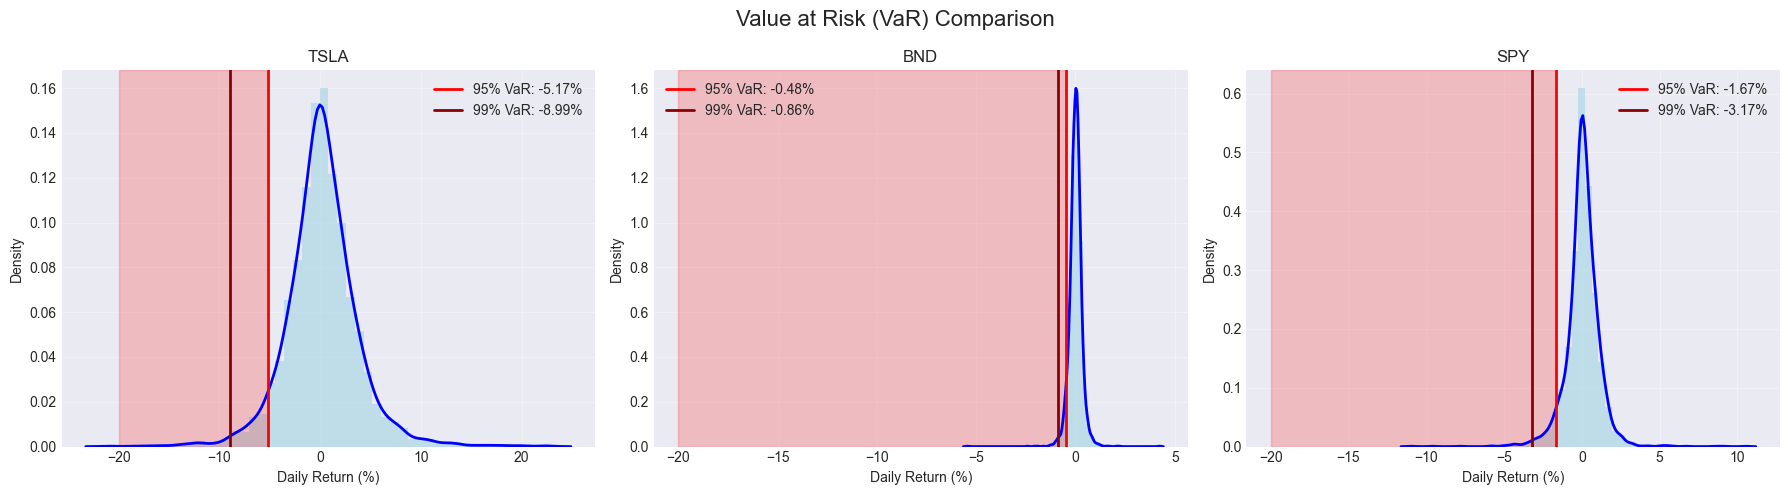

In [9]:
# Cell 9: Risk Metrics Calculation

def calculate_var(returns, confidence_level=0.95, method='historical'):
    """
    Calculate Value at Risk (VaR).
    
    Parameters:
    -----------
    returns : pd.Series
        Daily returns series
    confidence_level : float
        Confidence level (e.g., 0.95 for 95% VaR)
    method : str
        'historical' or 'parametric'
    
    Returns:
    --------
    float : VaR value in percentage terms
    """
    returns_clean = returns.dropna()
    
    if method == 'historical':
        # Historical VaR - use percentile
        var = np.percentile(returns_clean, (1 - confidence_level) * 100)
    elif method == 'parametric':
        # Parametric VaR - assumes normal distribution
        mu = returns_clean.mean()
        sigma = returns_clean.std()
        z_score = stats.norm.ppf(1 - confidence_level)
        var = mu + z_score * sigma
    else:
        raise ValueError("Method must be 'historical' or 'parametric'")
    
    return var

def calculate_cvar(returns, confidence_level=0.95):
    """
    Calculate Conditional VaR (Expected Shortfall).
    
    Parameters:
    -----------
    returns : pd.Series
        Daily returns series
    confidence_level : float
        Confidence level (e.g., 0.95 for 95% CVaR)
    
    Returns:
    --------
    float : CVaR value in percentage terms
    """
    returns_clean = returns.dropna()
    var = calculate_var(returns_clean, confidence_level, method='historical')
    cvar = returns_clean[returns_clean <= var].mean()
    return cvar

def calculate_sharpe_ratio(returns, risk_free_rate=0.02, periods=252):
    """
    Calculate Sharpe Ratio.
    
    Parameters:
    -----------
    returns : pd.Series
        Daily returns series
    risk_free_rate : float
        Annual risk-free rate (e.g., 0.02 for 2%)
    periods : int
        Number of periods per year (252 for daily)
    
    Returns:
    --------
    float : Sharpe Ratio
    """
    returns_clean = returns.dropna()
    
    # Annualize returns
    annual_return = returns_clean.mean() * periods
    annual_volatility = returns_clean.std() * np.sqrt(periods)
    
    # Calculate Sharpe ratio
    excess_return = annual_return - risk_free_rate * 100
    sharpe = excess_return / annual_volatility if annual_volatility > 0 else 0
    
    return sharpe

# Calculate metrics for all assets
risk_metrics = {}

for ticker in tickers:
    returns = returns_df[ticker]
    
    # Calculate VaR at different confidence levels
    var_95_historical = calculate_var(returns, confidence_level=0.95, method='historical')
    var_99_historical = calculate_var(returns, confidence_level=0.99, method='historical')
    var_95_parametric = calculate_var(returns, confidence_level=0.95, method='parametric')
    
    # Calculate CVaR
    cvar_95 = calculate_cvar(returns, confidence_level=0.95)
    cvar_99 = calculate_cvar(returns, confidence_level=0.99)
    
    # Calculate Sharpe Ratio
    sharpe = calculate_sharpe_ratio(returns, risk_free_rate=0.02)
    
    # Calculate additional metrics
    max_drawdown = ((returns.cumsum() - returns.cumsum().cummax()) / returns.cumsum().cummax() * 100).min()
    
    # Store results
    risk_metrics[ticker] = {
        'VaR_95_Historical': var_95_historical,
        'VaR_99_Historical': var_99_historical,
        'VaR_95_Parametric': var_95_parametric,
        'CVaR_95': cvar_95,
        'CVaR_99': cvar_99,
        'Sharpe_Ratio': sharpe,
        'Max_Drawdown': max_drawdown,
        'Annualized_Return': returns.mean() * 252,
        'Annualized_Volatility': returns.std() * np.sqrt(252)
    }

# Display risk metrics
print("📊 RISK METRICS COMPARISON")
print("="*80)
print("\n🔴 Value at Risk (VaR) - Maximum expected loss at given confidence level:")
print("-"*80)

metrics_df = pd.DataFrame(risk_metrics).T
display(metrics_df[['VaR_95_Historical', 'VaR_99_Historical', 'VaR_95_Parametric', 'CVaR_95', 'CVaR_99']])

print("\n📈 Performance Metrics:")
print("-"*80)
display(metrics_df[['Annualized_Return', 'Annualized_Volatility', 'Sharpe_Ratio', 'Max_Drawdown']])

# Visualize VaR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Value at Risk (VaR) Comparison', fontsize=16)

for idx, ticker in enumerate(tickers):
    returns = returns_df[ticker].dropna()
    
    # Histogram of returns
    axes[idx].hist(returns, bins=50, density=True, alpha=0.7, color='lightblue')
    sns.kdeplot(returns, ax=axes[idx], color='blue', linewidth=2)
    
    # Add VaR lines
    var_95 = risk_metrics[ticker]['VaR_95_Historical']
    var_99 = risk_metrics[ticker]['VaR_99_Historical']
    
    axes[idx].axvline(x=var_95, color='red', linestyle='-', linewidth=2, label=f'95% VaR: {var_95:.2f}%')
    axes[idx].axvline(x=var_99, color='darkred', linestyle='-', linewidth=2, label=f'99% VaR: {var_99:.2f}%')
    
    # Shade the loss region
    axes[idx].axvspan(-20, var_95, alpha=0.2, color='red')
    
    axes[idx].set_title(f'{ticker}', fontsize=12)
    axes[idx].set_xlabel('Daily Return (%)')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Summary and Key Insights

print("📋 TASK 1 COMPLETED - KEY FINDINGS SUMMARY")
print("="*80)

print("\n1️⃣ DATA OVERVIEW:")
print("-"*50)
print(f"   • Data period: {start_date} to {end_date}")
print(f"   • Total trading days: ~{len(cleaned_data['TSLA'])}")
print(f"   • Assets analyzed: {', '.join(tickers)}")
print("   • Data quality: All missing values handled, ready for modeling")

print("\n2️⃣ TREND ANALYSIS:")
print("-"*50)
for ticker in tickers:
    df = cleaned_data[ticker]
    start_price = df['Close'].iloc[0]
    end_price = df['Close'].iloc[-1]
    total_return = (end_price - start_price) / start_price * 100
    direction = "Upward" if total_return > 0 else "Downward"
    print(f"   • {ticker}: {direction} trend ({total_return:.1f}% total return)")

print("\n3️⃣ VOLATILITY CHARACTERISTICS:")
print("-"*50)
for ticker in tickers:
    vol = returns_df[ticker].std() * np.sqrt(252) * 100
    risk_profile = "High" if vol > 40 else "Medium" if vol > 20 else "Low"
    print(f"   • {ticker}: {vol:.1f}% annualized volatility ({risk_profile} risk)")
    print(f"     - Max daily gain: {returns_df[ticker].max():.2f}%")
    print(f"     - Max daily loss: {returns_df[ticker].min():.2f}%")

print("\n4️⃣ STATIONARITY TEST RESULTS:")
print("-"*50)
for ticker in tickers:
    p_value = adf_results_returns[ticker][1]
    is_stationary = "Stationary" if p_value <= 0.05 else "Non-stationary"
    print(f"   • {ticker}: {is_stationary} (p-value: {p_value:.4f})")

print("\n5️⃣ RISK METRICS (95% Confidence):")
print("-"*50)
for ticker in tickers:
    var = risk_metrics[ticker]['VaR_95_Historical']
    cvar = risk_metrics[ticker]['CVaR_95']
    sharpe = risk_metrics[ticker]['Sharpe_Ratio']
    print(f"   • {ticker}:")
    print(f"     - VaR (95%): {var:.2f}% (max daily loss)")
    print(f"     - CVaR (95%): {cvar:.2f}% (expected loss beyond VaR)")
    print(f"     - Sharpe Ratio: {sharpe:.3f}")

print("\n6️⃣ PORTFOLIO IMPLICATIONS:")
print("-"*50)
print("   • TSLA: High risk, high return - suitable for aggressive growth")
print("   • BND: Low risk, stable returns - suitable for capital preservation")
print("   • SPY: Moderate risk, diversified exposure - suitable for core holdings")
print("\n   📌 RECOMMENDATION: A balanced portfolio should consider")
print("   combining these assets to achieve desired risk-return profile")

print("\n7️⃣ MODELING READINESS:")
print("-"*50)
print("   ✅ Data is clean and ready for modeling")
print("   ✅ Returns are stationary (d=1 confirmed)")
print("   ✅ Risk metrics calculated for portfolio optimization")
print("   ✅ All analyses complete for Task 1")



📋 TASK 1 COMPLETED - KEY FINDINGS SUMMARY

1️⃣ DATA OVERVIEW:
--------------------------------------------------
   • Data period: 2015-01-01 to 2026-06-30
   • Total trading days: ~2888
   • Assets analyzed: TSLA, BND, SPY
   • Data quality: All missing values handled, ready for modeling

2️⃣ TREND ANALYSIS:
--------------------------------------------------
   • TSLA: Upward trend (2716.8% total return)
   • BND: Upward trend (24.1% total return)
   • SPY: Upward trend (336.7% total return)

3️⃣ VOLATILITY CHARACTERISTICS:
--------------------------------------------------
   • TSLA: 5717.7% annualized volatility (High risk)
     - Max daily gain: 22.69%
     - Max daily loss: -21.06%
   • BND: 531.2% annualized volatility (High risk)
     - Max daily gain: 4.22%
     - Max daily loss: -5.44%
   • SPY: 1765.5% annualized volatility (High risk)
     - Max daily gain: 10.50%
     - Max daily loss: -10.94%

4️⃣ STATIONARITY TEST RESULTS:
-------------------------------------------------

In [11]:
# Cell 11: Save Processed Data

# Define path for processed data
processed_data_path = '../data/processed/'

# Save cleaned data for each asset
for ticker, df in cleaned_data.items():
    file_path = f"{processed_data_path}{ticker}_cleaned.csv"
    df.to_csv(file_path)
    print(f"✅ Saved cleaned data for {ticker} to {file_path}")

# Save returns data
returns_df.to_csv(f"{processed_data_path}all_returns.csv")
print(f"✅ Saved all returns data to {processed_data_path}all_returns.csv")

# Save risk metrics
metrics_df.to_csv(f"{processed_data_path}risk_metrics.csv")
print(f"✅ Saved risk metrics to {processed_data_path}risk_metrics.csv")

print("\n📁 All processed data saved successfully!")

✅ Saved cleaned data for TSLA to ../data/processed/TSLA_cleaned.csv
✅ Saved cleaned data for BND to ../data/processed/BND_cleaned.csv
✅ Saved cleaned data for SPY to ../data/processed/SPY_cleaned.csv
✅ Saved all returns data to ../data/processed/all_returns.csv
✅ Saved risk metrics to ../data/processed/risk_metrics.csv

📁 All processed data saved successfully!
